# Project 5 — Module 6: Supervised Machine Learning
## Lesson 4 & 5: Regression Models & Classification Contrast

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 4 — Modeling |
| **Module** | 6 — Supervised Machine Learning (Alkemy Bootcamp) |
| **Dataset** | PequeShop — features_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook implements three models following the MVA principle:
> Linear Regression (baseline), Polynomial Regression (degree=2), and
> KNN Regressor (contrast with classification concept from L5).
> All models use the preprocessor pipeline from notebook 03.
> Results feed directly into notebook 05 for formal evaluation.


## Table of Contents

1. [CRISP-DM Phase 4 — Modeling](#1-crisp-dm-phase-4--modeling)
2. [Environment Setup](#2-environment-setup)
3. [Load Data & Preprocessor](#3-load-data--preprocessor)
4. [Baseline — Mean Predictor](#4-baseline--mean-predictor)
5. [Model 1 — Linear Regression](#5-model-1--linear-regression)
6. [Model 2 — Polynomial Regression](#6-model-2--polynomial-regression)
7. [Model 3 — KNN Regressor (L5 Contrast)](#7-model-3--knn-regressor-l5-contrast)
8. [Model Comparison — Preliminary](#8-model-comparison--preliminary)
9. [LEAN Filter — Waste Elimination Review](#9-lean-filter--waste-elimination-review)
10. [Decisions Log — Lessons 4 & 5](#10-decisions-log--lessons-4--5)
11. [Next Steps — Lesson 6 Preview](#11-next-steps--lesson-6-preview)


---
## 1. CRISP-DM Phase 4 — Modeling

### 1.1 Modeling Strategy

Following the MVA principle — start simple, add complexity only when justified:

```
Mean predictor (floor baseline)
        ↓
Linear Regression (interpretable baseline)
        ↓
Polynomial Regression (non-linear extension)
        ↓
KNN Regressor (distance-based, L5 contrast)
        ↓
Ridge / Lasso / GradientBoosting (notebooks 05-06)
```

### 1.2 L5 — Classification vs Regression Contrast

The consigna requires understanding why classification is not appropriate
for this task. KNN is used here as a bridge concept:

| KNN as Classifier | KNN as Regressor |
|------------------|------------------|
| Assigns class label (majority vote of k neighbors) | Predicts average value of k neighbors |
| Output: category (Promoter/Passive/Detractor) | Output: continuous value (CLP) |
| Metric: accuracy, F1 | Metric: MAE, RMSE, R² |
| Appropriate for churn prediction (Yes/No) | Appropriate for avg_ticket prediction |

> **Conclusion:** For predicting `avg_ticket` (continuous), KNN Regressor
> is correct. KNN Classifier would require discretizing the target —
> losing precision and business value.


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PROCESSED  = Path('../data/processed')
DATA_FINAL      = Path('../data/final')
REPORTS_FIGURES = Path('../reports/figures')
MODELS_PATH     = Path('../models')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


---
## 3. Load Data & Preprocessor


In [2]:
# ===== Load Data =====
df_customers    = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')
df_transactions = pd.read_csv(DATA_PROCESSED / 'transactions_final.csv')

# Platform per customer
platform_map = (
    df_transactions.groupby('customer_id')['platform']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'platform': 'primary_platform'})
)
df_merged = df_customers.merge(platform_map, on='customer_id', how='left')

CATEGORICAL_FEATURES = ['primary_platform', 'retargeting_segment']
NUMERIC_FEATURES     = ['total_transactions', 'total_revenue']
TARGET               = 'avg_ticket'

df_model = df_merged[CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TARGET]].dropna()
X = df_model[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df_model[TARGET]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Load preprocessor from notebook 03
preprocessor = joblib.load(MODELS_PATH / 'preprocessor_v1.pkl')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train mean: ${y_train.mean():,.0f} | y_test mean: ${y_test.mean():,.0f}')
print('Preprocessor loaded ✅')

X_train: (313, 4) | X_test: (79, 4)
y_train mean: $30,876 | y_test mean: $30,797
Preprocessor loaded ✅


---
## 4. Baseline — Mean Predictor

> Any model that does not beat this baseline adds no business value.


In [3]:
# ===== Baseline — Mean Predictor =====
y_pred_baseline = np.full(len(y_test), y_train.mean())

baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)

print('BASELINE — Mean Predictor')
print('=' * 40)
print(f'MAE  : ${baseline_mae:,.0f} CLP')
print(f'RMSE : ${baseline_rmse:,.0f} CLP')
print(f'R²   : {baseline_r2:.4f}')
print()
print('> All models must beat this baseline to justify deployment.')

BASELINE — Mean Predictor
MAE  : $8,507 CLP
RMSE : $11,051 CLP
R²   : -0.0001

> All models must beat this baseline to justify deployment.


---
## 5. Model 1 — Linear Regression


In [4]:
# ===== Linear Regression Pipeline =====
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred_train_lr = pipe_lr.predict(X_train)
y_pred_test_lr  = pipe_lr.predict(X_test)

lr_results = {
    'MAE train' : mean_absolute_error(y_train, y_pred_train_lr),
    'MAE test'  : mean_absolute_error(y_test,  y_pred_test_lr),
    'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train_lr)),
    'RMSE test' : np.sqrt(mean_squared_error(y_test,  y_pred_test_lr)),
    'R2 train'  : r2_score(y_train, y_pred_train_lr),
    'R2 test'   : r2_score(y_test,  y_pred_test_lr)
}

print('MODEL 1 — Linear Regression')
print('=' * 40)
for k, v in lr_results.items():
    unit = ' CLP' if 'MAE' in k or 'RMSE' in k else ''
    print(f'{k:<15}: {v:,.4f}{unit}')

# Save model
joblib.dump(pipe_lr, MODELS_PATH / 'model_lr_v1.pkl')
print('\n✅ Model saved: models/model_lr_v1.pkl')

MODEL 1 — Linear Regression
MAE train      : 5,948.4947 CLP
MAE test       : 5,582.0204 CLP
RMSE train     : 8,888.9704 CLP
RMSE test      : 7,604.2624 CLP
R2 train       : 0.6782
R2 test        : 0.5265

✅ Model saved: models/model_lr_v1.pkl


LINEAR REGRESSION — Coefficients
(Interpretation: 1 unit increase in feature → coefficient change in avg_ticket CLP)



,Feature,Coefficient
4,total_revenue,28800.079725
0,primary_platform_shopify,-1499.179382
2,retargeting_segment_Dormant,-1510.433645
1,retargeting_segment_At Risk,-3263.615607
3,total_transactions,-24941.819309


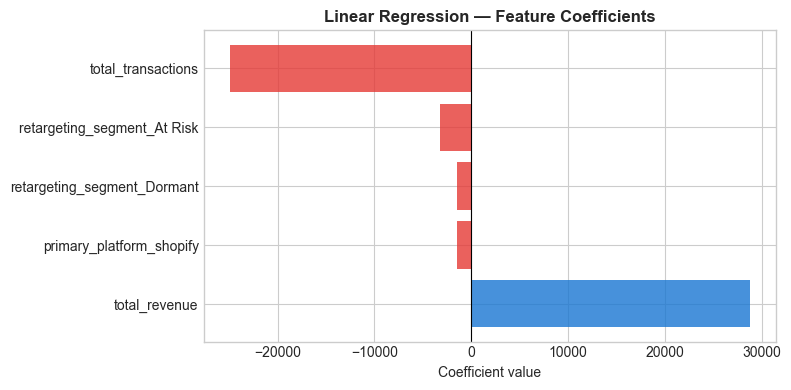

Figure saved: ..\reports\figures\04_lr_coefficients.png


In [5]:
# ===== Linear Regression — Coefficient Interpretation =====
lr_model     = pipe_lr.named_steps['model']
prep         = pipe_lr.named_steps['preprocessor']
cat_names    = prep.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(cat_names) + NUMERIC_FEATURES

df_coef = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print('LINEAR REGRESSION — Coefficients')
print('(Interpretation: 1 unit increase in feature → coefficient change in avg_ticket CLP)')
print()
display(df_coef)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1976D2' if c >= 0 else '#E53935' for c in df_coef['Coefficient']]
ax.barh(df_coef['Feature'], df_coef['Coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Linear Regression — Feature Coefficients', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
out = REPORTS_FIGURES / '04_lr_coefficients.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 6. Model 2 — Polynomial Regression


In [6]:
# ===== Polynomial Regression Pipeline (degree=2) =====
pipe_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

pipe_poly.fit(X_train, y_train)

y_pred_train_poly = pipe_poly.predict(X_train)
y_pred_test_poly  = pipe_poly.predict(X_test)

poly_results = {
    'MAE train' : mean_absolute_error(y_train, y_pred_train_poly),
    'MAE test'  : mean_absolute_error(y_test,  y_pred_test_poly),
    'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train_poly)),
    'RMSE test' : np.sqrt(mean_squared_error(y_test,  y_pred_test_poly)),
    'R2 train'  : r2_score(y_train, y_pred_train_poly),
    'R2 test'   : r2_score(y_test,  y_pred_test_poly)
}

print('MODEL 2 — Polynomial Regression (degree=2)')
print('=' * 45)
for k, v in poly_results.items():
    unit = ' CLP' if 'MAE' in k or 'RMSE' in k else ''
    print(f'{k:<15}: {v:,.4f}{unit}')

joblib.dump(pipe_poly, MODELS_PATH / 'model_poly_v1.pkl')
print('\n✅ Model saved: models/model_poly_v1.pkl')

MODEL 2 — Polynomial Regression (degree=2)
MAE train      : 3,315.0865 CLP
MAE test       : 3,114.8395 CLP
RMSE train     : 4,947.3814 CLP
RMSE test      : 4,469.7981 CLP
R2 train       : 0.9003
R2 test        : 0.8364

✅ Model saved: models/model_poly_v1.pkl


---
## 7. Model 3 — KNN Regressor (L5 Contrast)

> KNN is included as required by L5 — to contrast regression vs classification.
> KNN Regressor predicts the mean of the k nearest neighbors.
> KNN Classifier would assign the majority class — inappropriate for continuous target.


In [7]:
# ===== KNN Regressor Pipeline =====
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

pipe_knn.fit(X_train, y_train)

y_pred_train_knn = pipe_knn.predict(X_train)
y_pred_test_knn  = pipe_knn.predict(X_test)

knn_results = {
    'MAE train' : mean_absolute_error(y_train, y_pred_train_knn),
    'MAE test'  : mean_absolute_error(y_test,  y_pred_test_knn),
    'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train_knn)),
    'RMSE test' : np.sqrt(mean_squared_error(y_test,  y_pred_test_knn)),
    'R2 train'  : r2_score(y_train, y_pred_train_knn),
    'R2 test'   : r2_score(y_test,  y_pred_test_knn)
}

print('MODEL 3 — KNN Regressor (k=5)')
print('=' * 40)
for k, v in knn_results.items():
    unit = ' CLP' if 'MAE' in k or 'RMSE' in k else ''
    print(f'{k:<15}: {v:,.4f}{unit}')

joblib.dump(pipe_knn, MODELS_PATH / 'model_knn_v1.pkl')
print('\n✅ Model saved: models/model_knn_v1.pkl')

MODEL 3 — KNN Regressor (k=5)
MAE train      : 2,837.9098 CLP
MAE test       : 3,364.3115 CLP
RMSE train     : 6,883.8567 CLP
RMSE test      : 6,290.0556 CLP
R2 train       : 0.8070
R2 test        : 0.6760

✅ Model saved: models/model_knn_v1.pkl


---
## 8. Model Comparison — Preliminary


PRELIMINARY MODEL COMPARISON


,Model,MAE test,RMSE test,R2 test,R2 train,Beats baseline?,Overfit gap
0,Baseline (mean),8507.4656,11051.3739,-0.0001,-0.0001,False,0.0000
1,Linear Regression,5582.0204,7604.2624,0.5265,0.6782,True,0.1517
2,Polynomial (deg=2),3114.8395,4469.7981,0.8364,0.9003,True,0.0639
3,KNN (k=5),3364.3115,6290.0556,0.6760,0.8070,True,0.1310


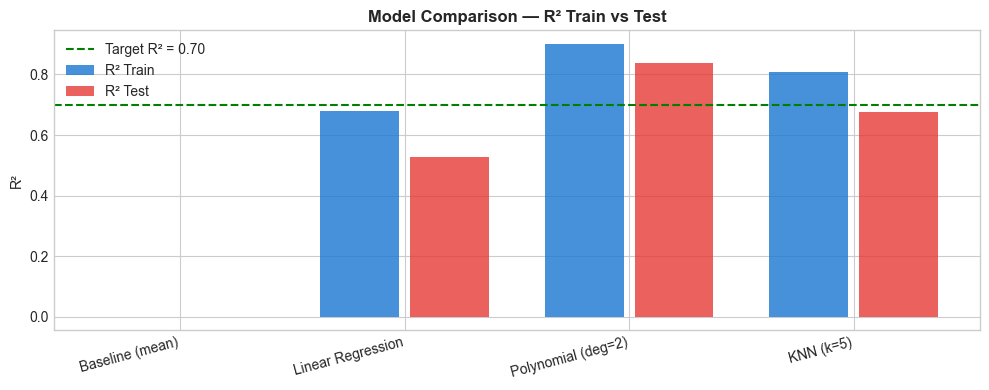

Figure saved: ..\reports\figures\04_model_comparison.png


In [8]:
# ===== Preliminary Model Comparison =====
comparison = pd.DataFrame({
    'Model'     : ['Baseline (mean)', 'Linear Regression', 'Polynomial (deg=2)', 'KNN (k=5)'],
    'MAE test'  : [baseline_mae,  lr_results['MAE test'],   poly_results['MAE test'],  knn_results['MAE test']],
    'RMSE test' : [baseline_rmse, lr_results['RMSE test'],  poly_results['RMSE test'], knn_results['RMSE test']],
    'R2 test'   : [baseline_r2,   lr_results['R2 test'],    poly_results['R2 test'],   knn_results['R2 test']],
    'R2 train'  : [baseline_r2,   lr_results['R2 train'],   poly_results['R2 train'],  knn_results['R2 train']]
})

comparison['Beats baseline?'] = comparison['R2 test'] > baseline_r2
comparison['Overfit gap']     = (comparison['R2 train'] - comparison['R2 test']).round(4)

print('PRELIMINARY MODEL COMPARISON')
display(comparison.round(4))

# Visualization
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison))
ax.bar(x - 0.2, comparison['R2 train'], width=0.35, label='R² Train',
       color='#1976D2', alpha=0.8)
ax.bar(x + 0.2, comparison['R2 test'],  width=0.35, label='R² Test',
       color='#E53935', alpha=0.8)
ax.axhline(0.70, color='green', linestyle='--', lw=1.5, label='Target R² = 0.70')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=15, ha='right')
ax.set_title('Model Comparison — R² Train vs Test', fontsize=12, fontweight='bold')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
out = REPORTS_FIGURES / '04_model_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 9. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Did we start with simplest model first? | ✅ Yes — mean predictor → linear → polynomial → KNN | MVA principle |
| Is KNN included for business value or consigna compliance? | ✅ Both — L5 contrast + valid regressor | Keep |
| Are models saved as .pkl? | ✅ Yes — reused in notebook 05 | No re-training |
| Did we interpret coefficients? | ✅ Yes — required by L4 consigna | Keep |
| Is polynomial degree=2 sufficient? | ✅ Yes — higher degrees risk overfitting with n=392 | MVA principle |


---
## 10. Decisions Log — Lessons 4 & 5

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Start with mean predictor baseline | Without a floor benchmark, model performance has no reference point | Skip baseline | ✅ Industry standard |
| 2 | Polynomial degree=2 | Captures non-linear relationships without excessive complexity; degree=3+ risks overfitting with n=392 | degree=3 | ✅ MVA principle |
| 3 | KNN k=5 initial | Standard starting point; optimal k determined in notebook 05 via GridSearchCV | k=3 or k=10 | ✅ Reasonable default |
| 4 | KNN Regressor not Classifier (L5) | avg_ticket is continuous — classifier requires arbitrary discretization and loses precision | KNN Classifier with spend tiers | ✅ Correct problem framing |
| 5 | Save all models as .pkl | Reused in notebooks 05-06; no re-training needed | Re-train in each notebook | ✅ MLOps + no re-work |


---
## 11. Next Steps — Lesson 6 Preview

In **Lesson 6 & 7 — Evaluation (notebook 05)**, the following tasks will
be completed:

1. Calculate MAE, MSE, RMSE and R² for all models
2. Build complete model comparison table
3. Optimize KNN with GridSearchCV (find best k)
4. Apply Ridge regularization (L2 penalty)
5. Apply Lasso regularization (L1 penalty — feature selection)
6. Compare all models and identify best performer

---

**Previous:** [03 - Data Preparation](./03_data_preparation.ipynb)  
**Next Phase -->** [05 - Evaluation](./05_evaluation.ipynb)

*Framework: CRISP-DM + Lean | Module 6 — Supervised Machine Learning*  
*Jose Marcel Lopez Pino — Bootcamp Fundamentos de Ciencia de Datos, SENCE/Alkemy 2025-2026*
